## Load

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score as ps
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, precision_score,recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [74]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle (2).json to kaggle (2) (2).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [75]:
!kaggle datasets download -d shayanfazeli/heartbeat
!unzip heartbeat.zip

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
heartbeat.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heartbeat.zip
replace mitbih_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace mitbih_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ptbdb_abnormal.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ptbdb_normal.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [76]:
TRAIN_PATH = "mitbih_train.csv"
TEST_PATH  = "mitbih_test.csv"

df_train = pd.read_csv(TRAIN_PATH, header=None)
df_test  = pd.read_csv(TEST_PATH,  header=None)

print(f"Train shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")

Train shape : (87554, 188)
Test shape  : (21892, 188)


In [77]:
df_train.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
0,87554.0,0.890360,0.240909,0.0,0.921922,0.991342,1.000000,1.0
1,87554.0,0.758160,0.221813,0.0,0.682486,0.826013,0.910506,1.0
2,87554.0,0.423972,0.227305,0.0,0.250969,0.429472,0.578767,1.0
3,87554.0,0.219104,0.206878,0.0,0.048458,0.166000,0.341727,1.0
4,87554.0,0.201127,0.177058,0.0,0.082329,0.147878,0.258993,1.0
5,87554.0,0.210399,0.171909,0.0,0.088416,0.158798,0.287628,1.0
6,87554.0,0.205808,0.178481,0.0,0.073333,0.145324,0.298237,1.0
7,87554.0,0.201773,0.177240,0.0,0.066116,0.144424,0.295391,1.0
8,87554.0,0.198691,0.171778,0.0,0.065000,0.150000,0.290832,1.0
9,87554.0,0.196757,0.168357,0.0,0.068639,0.148734,0.283636,1.0


In [78]:
LABEL_COL = df_train.shape[1] - 1
print("Label column index:", LABEL_COL)

class_names = {
    0: "Normal (N)",
    1: "Supraventricular (S)",
    2: "Ventricular (V)",
    3: "Fusion (F)",
    4: "Unknown / Paced (Q)"
}
class_names

Label column index: 187


{0: 'Normal (N)',
 1: 'Supraventricular (S)',
 2: 'Ventricular (V)',
 3: 'Fusion (F)',
 4: 'Unknown / Paced (Q)'}

In [79]:
class_counts = df_train[LABEL_COL].value_counts().sort_index()
class_percent = (class_counts / class_counts.sum() * 100).round(2)

dist_df = pd.DataFrame({
    "Class": [class_names[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage (%)": class_percent.values
})
dist_df

,Class,Count,Percentage (%)
0,Normal (N),72471,82.77
1,Supraventricular (S),2223,2.54
2,Ventricular (V),5788,6.61
3,Fusion (F),641,0.73
4,Unknown / Paced (Q),6431,7.35


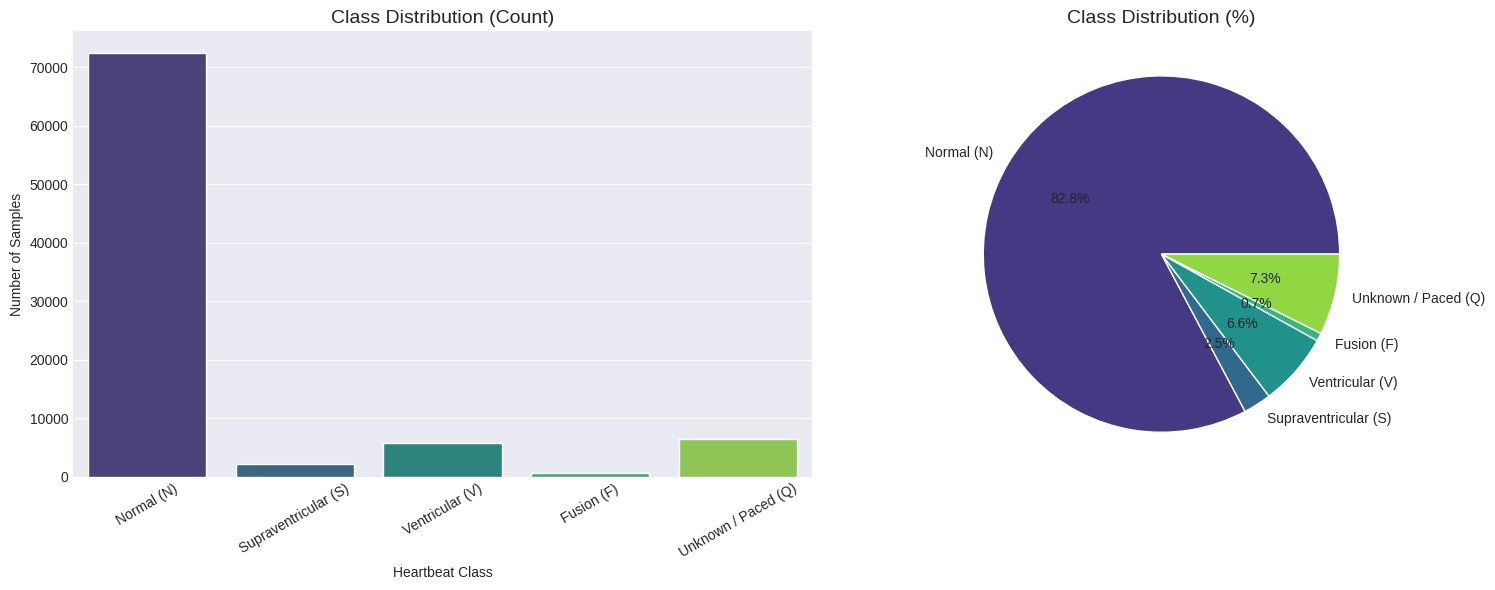

In [80]:
ig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=dist_df["Class"], y=dist_df["Count"], ax=axes[0], palette="viridis")
axes[0].set_title("Class Distribution (Count)", fontsize=14)
axes[0].set_xlabel("Heartbeat Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(dist_df["Count"], labels=dist_df["Class"], autopct='%1.1f%%',
            colors=sns.color_palette("viridis", len(dist_df)))
axes[1].set_title("Class Distribution (%)", fontsize=14)

plt.tight_layout()
plt.show()


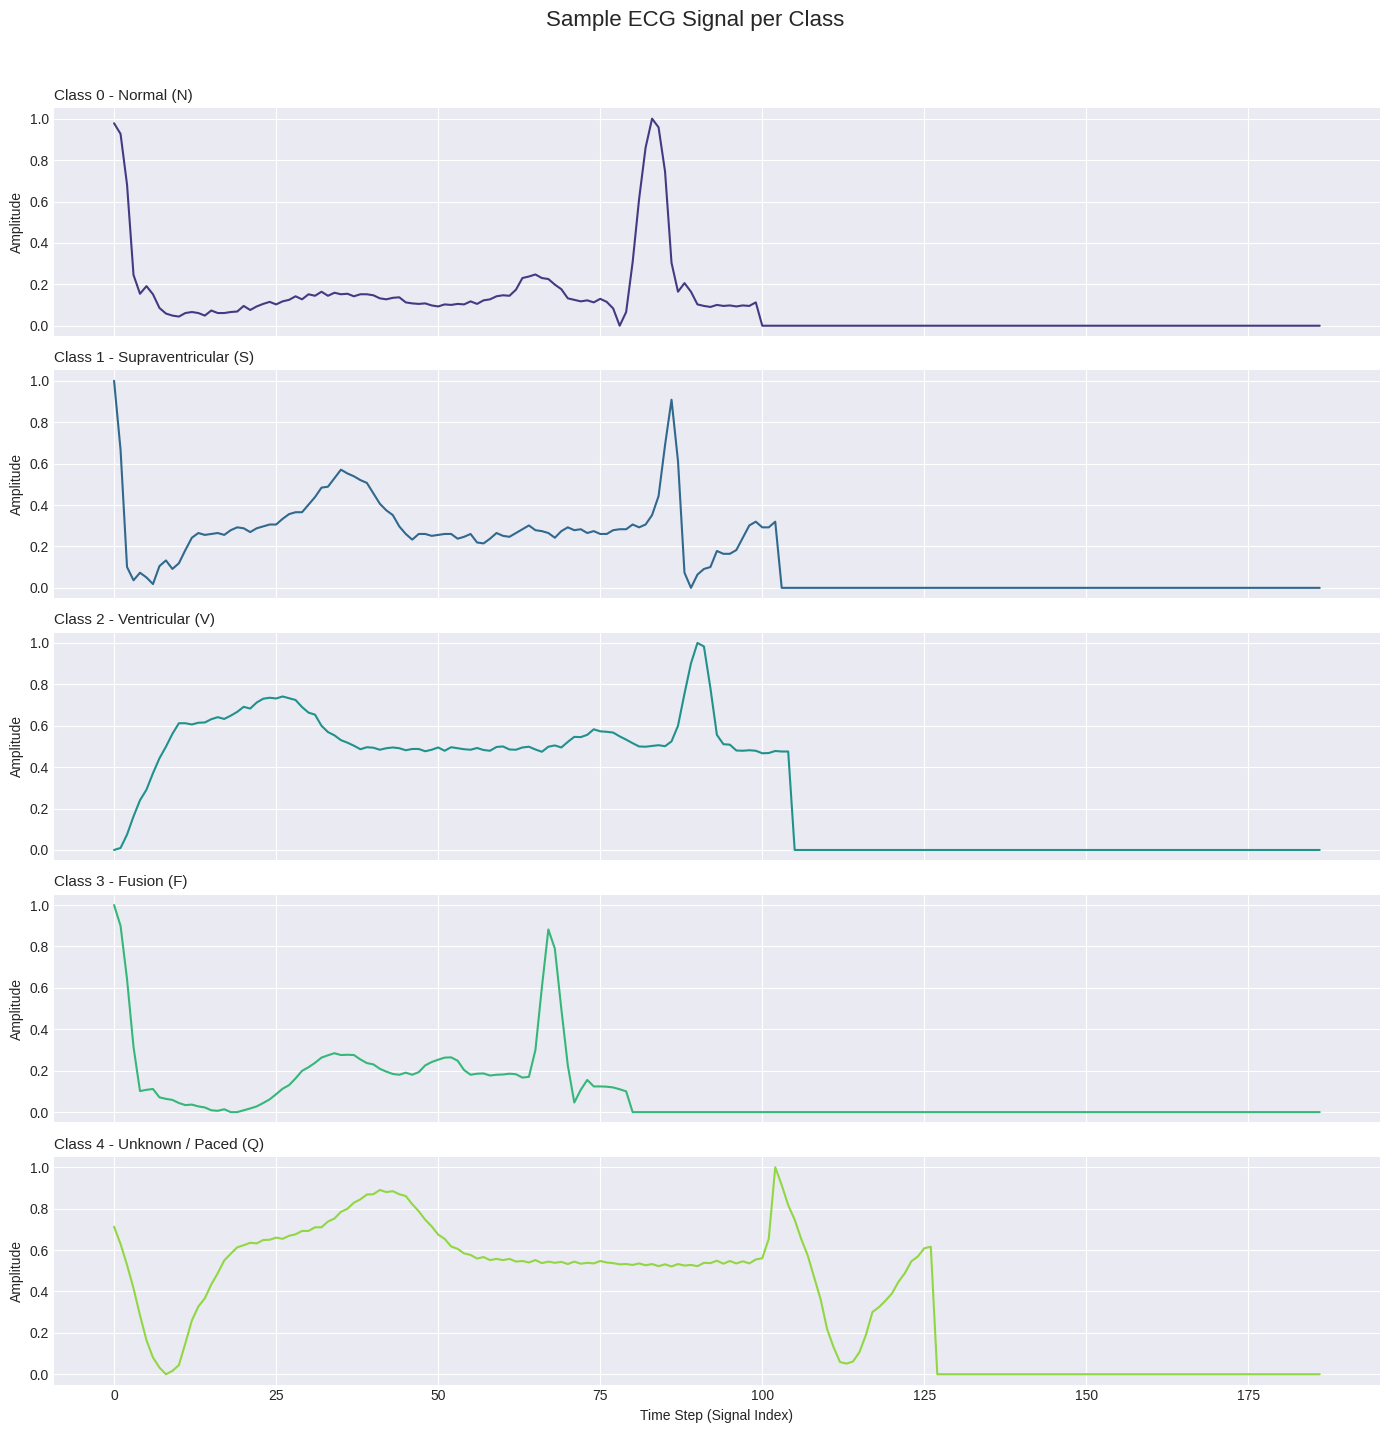

In [81]:
fig, axes = plt.subplots(len(class_names), 1, figsize=(14, 14), sharex=True)

for i, (cls, name) in enumerate(class_names.items()):
    sample = df_train[df_train[LABEL_COL] == cls].iloc[0, :LABEL_COL].values
    axes[i].plot(sample, color=sns.color_palette("viridis", len(class_names))[i])
    axes[i].set_title(f"Class {cls} - {name}", fontsize=11, loc='left')
    axes[i].set_ylabel("Amplitude")

axes[-1].set_xlabel("Time Step (Signal Index)")
plt.suptitle("Sample ECG Signal per Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

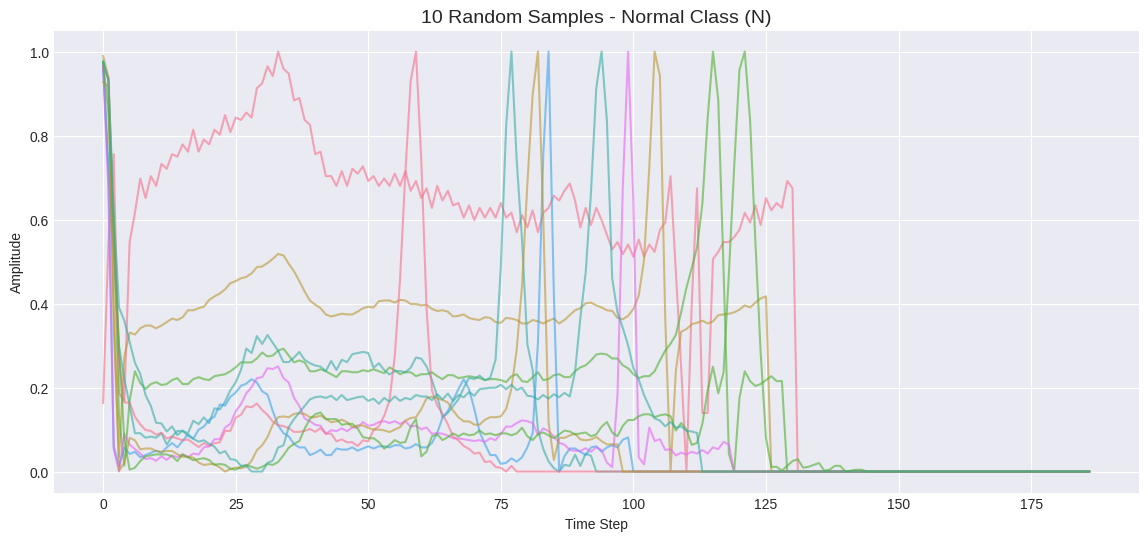

In [82]:
plt.figure(figsize=(14, 6))
normal_samples = df_train[df_train[LABEL_COL] == 0].sample(10, random_state=SEED)

for idx in range(10):
    plt.plot(normal_samples.iloc[idx, :LABEL_COL].values, alpha=0.6)

plt.title("10 Random Samples - Normal Class (N)", fontsize=14)
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

## Preprocessing

In [83]:
X_train_full = df_train.iloc[:, :LABEL_COL].values
y_train_full = df_train.iloc[:, LABEL_COL].values.astype(int)

X_test = df_test.iloc[:, :LABEL_COL].values
y_test = df_test.iloc[:, LABEL_COL].values.astype(int)

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train_full shape: (87554, 187)
y_train_full shape: (87554,)
X_test shape: (21892, 187)
y_test shape: (21892,)


In [84]:
missing_train = df_train.isnull().sum().sum()
missing_test  = df_test.isnull().sum().sum()

print(f"Total missing values in Train: {missing_train}")
print(f"Total missing values in Test : {missing_test}")

if missing_train > 0 or missing_test > 0:
    print(" Have missing value")
else:
    print("Don't have missing value ")

Total missing values in Train: 0
Total missing values in Test : 0
Don't have missing value 


In [85]:
if missing_train > 0:
    df_train = df_train.fillna(df_train.median())

if missing_test > 0:
    df_test = df_test.fillna(df_test.median())

X_train_full = df_train.iloc[:, :LABEL_COL].values
y_train_full = df_train.iloc[:, LABEL_COL].values.astype(int)
X_test = df_test.iloc[:, :LABEL_COL].values
y_test = df_test.iloc[:, LABEL_COL].values.astype(int)

In [86]:
dup_train = df_train.duplicated().sum()
dup_test  = df_test.duplicated().sum()

print(f"Duplicate rows in Train: {dup_train}")
print(f"Duplicate rows in Test : {dup_test}")

Duplicate rows in Train: 0
Duplicate rows in Test : 0


In [87]:
before_train = df_train.shape[0]
df_train = df_train.drop_duplicates().reset_index(drop=True)
after_train = df_train.shape[0]
print(f"Train: removed {before_train - after_train} duplicate rows")

before_test = df_test.shape[0]
df_test = df_test.drop_duplicates().reset_index(drop=True)
after_test = df_test.shape[0]
print(f"Test: removed {before_test - after_test} duplicate rows")

X_train_full = df_train.iloc[:, :LABEL_COL].values
y_train_full = df_train.iloc[:, LABEL_COL].values.astype(int)
X_test = df_test.iloc[:, :LABEL_COL].values
y_test = df_test.iloc[:, LABEL_COL].values.astype(int)

print("\nNew shapes -> X_train_full:", X_train_full.shape, " | X_test:", X_test.shape)

Train: removed 0 duplicate rows
Test: removed 0 duplicate rows

New shapes -> X_train_full: (87554, 187)  | X_test: (21892, 187)


In [88]:
df_balance = pd.DataFrame(X_train_full)
df_balance['label'] = y_train_full

class_dfs = {cls: df_balance[df_balance['label'] == cls] for cls in df_balance['label'].unique()}

for cls, d in class_dfs.items():
    print(f"Class {cls}: {len(d)} samples")

Class 0: 72471 samples
Class 1: 2223 samples
Class 2: 5788 samples
Class 3: 641 samples
Class 4: 6431 samples


In [89]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("Class distribution BEFORE:")
class_counts = {}
for cls in sorted(set(y_train_full)):
    cnt = (y_train_full == cls).sum()
    class_counts[cls] = cnt
    print(f"  Class {cls}: {cnt:6d}")

TARGET = 6000

sampling_strategy = {
    cls: max(cnt, TARGET) if cls != 0 else cnt
    for cls, cnt in class_counts.items()
}

sampling_strategy[0] = class_counts[0]

print(f"\nSampling targets:")
labels = {0:"Normal", 1:"Supra", 2:"Ventricular", 3:"Fusion", 4:"Unknown"}
for cls, target in sampling_strategy.items():
    orig = class_counts[cls]
    arrow = f"→ {target}" if target > orig else "→ unchanged"
    print(f"  Class {cls} {labels[cls]:12s}: {orig:6d}  {arrow}")

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=3,
    random_state=SEED
)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_full, y_train_full)

print("\nClass distribution AFTER SMOTE:")
for cls in sorted(set(y_train_balanced)):
    cnt = (y_train_balanced == cls).sum()
    pct = cnt / len(y_train_balanced) * 100
    bar = '█' * int(pct / 3)
    print(f"  Class {cls}: {cnt:6d}  ({pct:5.1f}%)  {bar}")

print(f"\nTotal: {len(X_train_balanced):,} samples")
print("SMOTE done!")


Class distribution BEFORE:
  Class 0:  72471
  Class 1:   2223
  Class 2:   5788
  Class 3:    641
  Class 4:   6431

Sampling targets:
  Class 0 Normal      :  72471  → unchanged
  Class 1 Supra       :   2223  → 6000
  Class 2 Ventricular :   5788  → 6000
  Class 3 Fusion      :    641  → 6000
  Class 4 Unknown     :   6431  → unchanged

Class distribution AFTER SMOTE:
  Class 0:  72471  ( 74.8%)  ████████████████████████
  Class 1:   6000  (  6.2%)  ██
  Class 2:   6000  (  6.2%)  ██
  Class 3:   6000  (  6.2%)  ██
  Class 4:   6431  (  6.6%)  ██

Total: 96,902 samples
SMOTE done!


In [90]:


def add_jitter_array(X, noise_level=0.005, seed=SEED):
    rng   = np.random.RandomState(seed)
    noise = rng.normal(loc=0.0, scale=noise_level, size=X.shape)
    return np.clip(X + noise, 0, 1)
X_train_balanced = add_jitter_array(X_train_balanced, noise_level=0.005)

print("  Jitter applied on SMOTE arrays directly")
print(f"   X_train_balanced shape : {X_train_balanced.shape}")
print("\nClass distribution AFTER balancing:")
print(pd.Series(y_train_balanced).value_counts().sort_index())


  Jitter applied on SMOTE arrays directly
   X_train_balanced shape : (96902, 187)

Class distribution AFTER balancing:
0    72471
1     6000
2     6000
3     6000
4     6431
Name: count, dtype: int64


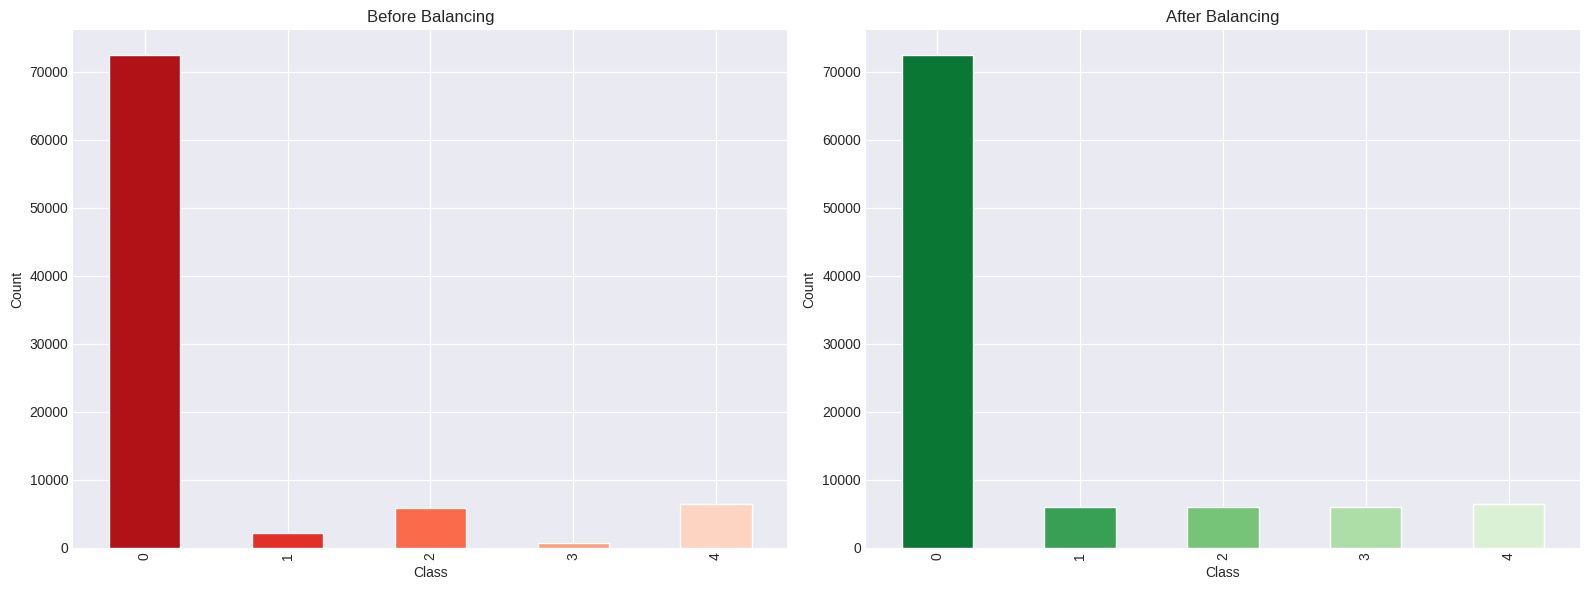

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pd.Series(y_train_full).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=sns.color_palette("Reds_r", 5))
axes[0].set_title("Before Balancing")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

pd.Series(y_train_balanced).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=sns.color_palette("Greens_r", 5))
axes[1].set_title("After Balancing")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [92]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.2674228312014461), 1: np.float64(3.2300666666666666), 2: np.float64(3.2300666666666666), 3: np.float64(3.2300666666666666), 4: np.float64(3.0135904213963616)}


In [93]:
scaler = StandardScaler()

X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("Train mean ~0:", round(X_train_balanced_scaled.mean(), 4),
      " | Train std ~1:", round(X_train_balanced_scaled.std(), 4))

Scaling done.
Train mean ~0: 0.0  | Train std ~1: 1.0


In [94]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_balanced_scaled, y_train_balanced,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_balanced
)

print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " | y_val  :", y_val.shape)
print("X_test :", X_test_scaled.shape, " | y_test :", y_test.shape)

X_train: (82366, 187)  | y_train: (82366,)
X_val  : (14536, 187)  | y_val  : (14536,)
X_test : (21892, 187)  | y_test : (21892,)


In [95]:
NUM_CLASSES = len(np.unique(y_train_full))
TIME_STEPS = X_train.shape[1]

X_train_dl = X_train.reshape(X_train.shape[0], TIME_STEPS, 1)
X_val_dl   = X_val.reshape(X_val.shape[0], TIME_STEPS, 1)
X_test_dl  = X_test_scaled.reshape(X_test_scaled.shape[0], TIME_STEPS, 1)

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test, num_classes=NUM_CLASSES)

print("X_train_dl:", X_train_dl.shape)
print("X_val_dl  :", X_val_dl.shape)
print("X_test_dl :", X_test_dl.shape)
print("NUM_CLASSES:", NUM_CLASSES)

X_train_dl: (82366, 187, 1)
X_val_dl  : (14536, 187, 1)
X_test_dl : (21892, 187, 1)
NUM_CLASSES: 5


# Models

In [96]:
def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            f"{model_name}_best.keras", monitor='val_loss',
            save_best_only=True, verbose=0
        )
    ]


## CNN

In [97]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

def focal_loss(gamma=2.0, alpha=None):

    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce     = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t    = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_w = tf.pow(1.0 - p_t, gamma)
        if alpha is not None:
            alpha_t = tf.reduce_sum(y_true * alpha, axis=-1)
            return tf.reduce_mean(alpha_t * focal_w * ce)
        return tf.reduce_mean(focal_w * ce)
    return loss_fn
ALPHA = tf.constant([0.3, 4.0, 1.5, 8.0, 1.5], dtype=tf.float32)

def build_cnn_model(time_steps, num_classes):
    model = models.Sequential([
        layers.Input(shape=(time_steps, 1)),

        layers.Conv1D(64, kernel_size=7, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        layers.Conv1D(128, kernel_size=5, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.25),

        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ], name="CNN_ECG_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=focal_loss(gamma=2.0, alpha=ALPHA),   # gamma=2 مع alpha مضبوط,   # ← Focal Loss هنا
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn_model(TIME_STEPS, NUM_CLASSES)
cnn_model.summary()


Model: "CNN_ECG_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 187, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 93, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 46, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 46, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 23, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 23, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │           64

 Total params: 440,197 (1.68 MB)

 Trainable params: 438,277 (1.67 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [98]:
STRONG_WEIGHTS = {
    0: 1.0,    # Normal       — ممتاز
    1: 15.0,   # Supra (S)    — precision=0.50 → نرفع
    2: 3.0,    # Ventricular  — precision=0.94 → كويس
    3: 25.0,   # Fusion (F)   — precision=0.43 → أعلى weight
    4: 2.0     # Unknown (Q)  — precision=0.98 → ممتاز
}

print("⚖️  Class Weights:")
labels = ["Normal","Supra","Ventricular","Fusion","Unknown"]
for cls, w in STRONG_WEIGHTS.items():
    print(f"  Class {cls} {labels[cls]:12s}: {w}x")


history_cnn = cnn_model.fit(
    X_train_dl, y_train_cat,
    validation_data=(X_val_dl, y_val_cat),
    epochs=80,
    batch_size=64,
    class_weight=STRONG_WEIGHTS,
    callbacks=get_callbacks("cnn_model"),
    verbose=1
)

⚖️  Class Weights:
  Class 0 Normal      : 1.0x
  Class 1 Supra       : 15.0x
  Class 2 Ventricular : 3.0x
  Class 3 Fusion      : 25.0x
  Class 4 Unknown     : 2.0x
Epoch 1/80
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.4311 - loss: 2.5713 - val_accuracy: 0.4487 - val_loss: 0.5513 - learning_rate: 3.0000e-04
Epoch 2/80
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6141 - loss: 1.3195 - val_accuracy: 0.5544 - val_loss: 0.3355 - learning_rate: 3.0000e-04
Epoch 3/80
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6904 - loss: 0.9847 - val_accuracy: 0.7608 - val_loss: 0.2857 - learning_rate: 3.0000e-04
Epoch 4/80
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7530 - loss: 0.7936 - val_accuracy: 0.6653 - val_loss: 0.2778 - learning_rate: 3.0000e-04
Epoch 5/80
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7890 - loss: 0.7015 - val_accuracy: 0.8331 - val_loss: 0.2241 - learning_rate: 3.0000e-04
Epoch 6/80
1287/1287 ━━━━━━━━━━━━━━━━━━━

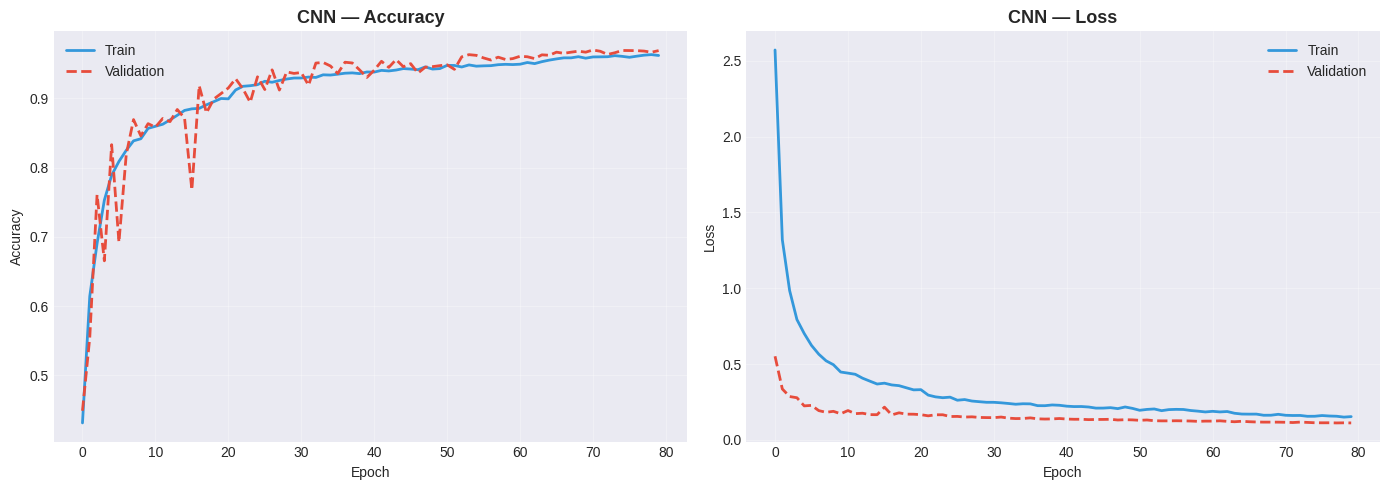

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'],     label='Train',      color='#3498db', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('CNN — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(history_cnn.history['loss'],     label='Train',      color='#3498db', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('CNN — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cnn_training_history.png', bbox_inches='tight')
plt.show()


In [100]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(X_val_dl, y_val_cat, verbose=0)
print(f"CNN — Val Loss: {cnn_val_loss:.4f}  |  Val Accuracy: {cnn_val_acc:.4f}")


CNN — Val Loss: 0.1116  |  Val Accuracy: 0.9684


## lSTM

In [101]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from google.colab import files
import numpy as np

print(" Put model.weights.h5 ...")
uploaded = files.upload()

def build_lstm_model(time_steps, num_classes):
    model = models.Sequential([
        layers.Input(shape=(time_steps, 1)),
        layers.Bidirectional(layers.LSTM(
            64, return_sequences=True,
            dropout=0.3, recurrent_dropout=0.2)),
        layers.BatchNormalization(),
        layers.Bidirectional(layers.LSTM(
            32, return_sequences=False,
            dropout=0.3, recurrent_dropout=0.2)),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="LSTM_ECG_Model")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model(TIME_STEPS, NUM_CLASSES)

lstm_model.load_weights('model.weights.h5')
print("LSTM weights loaded successfully!")
lstm_model.summary()


 Put model.weights.h5 ...


Saving model.weights.h5 to model.weights (2).h5
LSTM weights loaded successfully!


Model: "LSTM_ECG_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 187, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,261 (313.52 KB)

 Trainable params: 79,877 (312.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [102]:
lstm_scaler = StandardScaler()
lstm_scaler.fit(X_train_full)

X_test_lstm_scaled = lstm_scaler.transform(X_test)
X_test_lstm_dl     = X_test_lstm_scaled.reshape(-1, TIME_STEPS, 1)

print(f" Test data prepared for LSTM")
print(f"   Shape: {X_test_lstm_dl.shape}")




 Test data prepared for LSTM
   Shape: (21892, 187, 1)


## Evaluate Models

In [103]:
y_pred_cnn = np.argmax(cnn_model.predict(X_test_dl, verbose=0), axis=1)

acc  = accuracy_score(y_test, y_pred_cnn)
prec = precision_score(y_test, y_pred_cnn, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred_cnn, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred_cnn, average='weighted', zero_division=0)

print("  CNN - Test Set Evaluation")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print()
print("Classification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_cnn,
                             target_names=list(class_names.values()),
                             digits=4, zero_division=0))


  CNN - Test Set Evaluation
Accuracy : 0.9605
Precision: 0.9752
Recall   : 0.9605
F1-score : 0.9656

Classification Report:
                      precision    recall  f1-score   support

          Normal (N)     0.9958    0.9614    0.9783     18118
Supraventricular (S)     0.5397    0.8921    0.6725       556
     Ventricular (V)     0.9592    0.9406    0.9498      1448
          Fusion (F)     0.3680    0.9383    0.5287       162
 Unknown / Paced (Q)     0.9702    0.9938    0.9819      1608

            accuracy                         0.9605     21892
           macro avg     0.7666    0.9452    0.8222     21892
        weighted avg     0.9752    0.9605    0.9656     21892



In [104]:
y_pred_lstm_probs = lstm_model.predict(X_test_lstm_dl, verbose=0)
y_pred_lstm       = np.argmax(y_pred_lstm_probs, axis=1)

acc  = accuracy_score(y_test, y_pred_lstm)
prec = precision_score(y_test, y_pred_lstm, average='weighted', zero_division=0)
rec  = recall_score(y_test,   y_pred_lstm, average='weighted', zero_division=0)
f1   = f1_score(y_test,       y_pred_lstm, average='weighted', zero_division=0)

print("  LSTM — Test Set Evaluation ")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-score : {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lstm,
                             target_names=list(class_names.values()),
                             digits=4, zero_division=0))


  LSTM — Test Set Evaluation 
  Accuracy : 0.8344
  Precision: 0.9255
  Recall   : 0.8344
  F1-score : 0.8646

Classification Report:

                      precision    recall  f1-score   support

          Normal (N)     0.9930    0.8178    0.8969     18118
Supraventricular (S)     0.2532    0.7896    0.3834       556
     Ventricular (V)     0.6393    0.9047    0.7492      1448
          Fusion (F)     0.1383    0.9198    0.2405       162
 Unknown / Paced (Q)     0.7352    0.9652    0.8346      1608

            accuracy                         0.8344     21892
           macro avg     0.5518    0.8794    0.6209     21892
        weighted avg     0.9255    0.8344    0.8646     21892



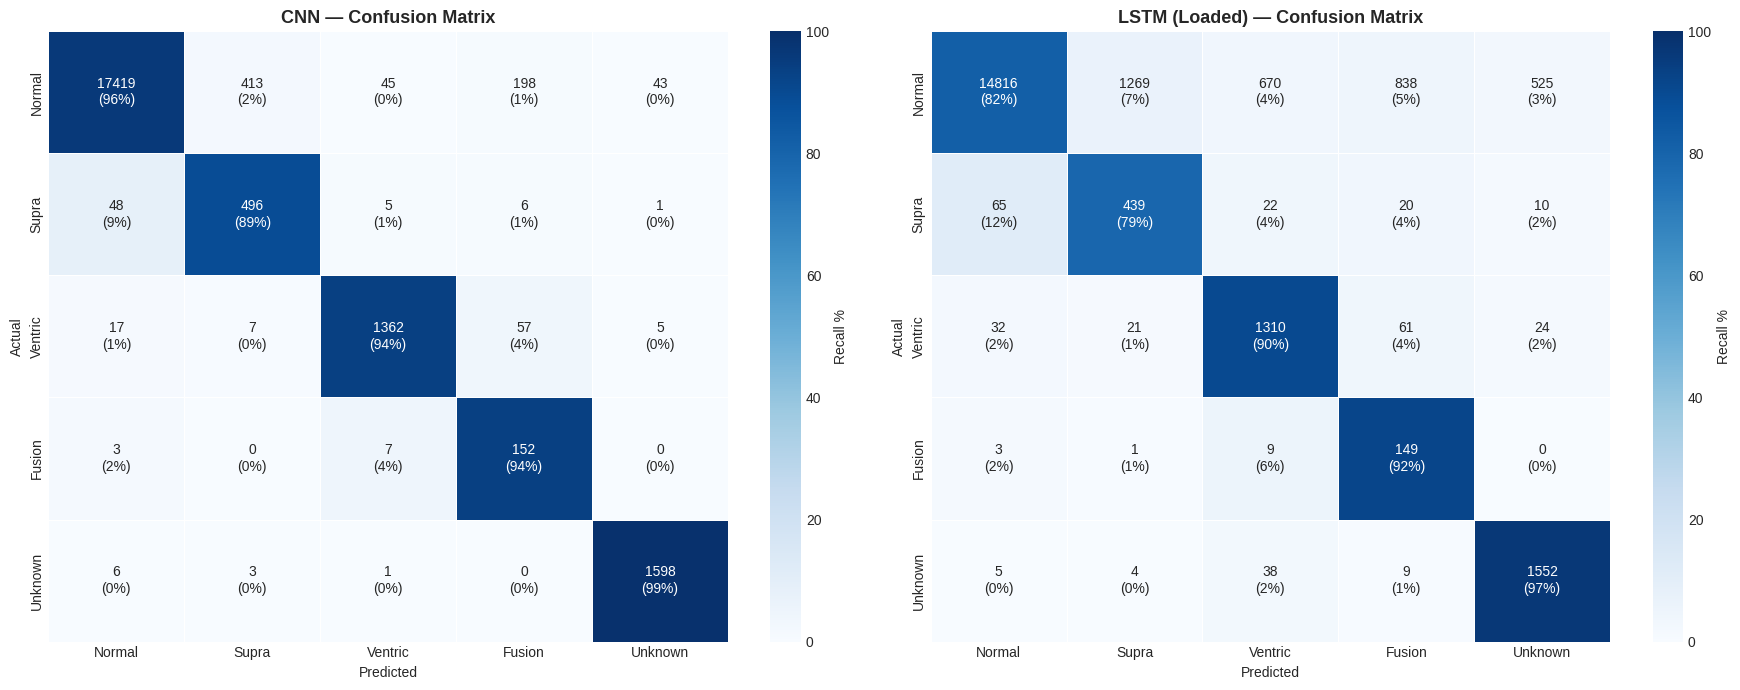


 CNN vs LSTM — Comparison:


,Accuracy,Macro F1,Prec Normal,Prec Supra,Prec Ventric,Prec Fusion,Prec Unknown
Model,,,,,,,
CNN,0.9605,0.8222,0.9958,0.5397,0.9592,0.3680,0.9702
LSTM (Loaded),0.8344,0.6209,0.9930,0.2532,0.6393,0.1383,0.7352


In [105]:
y_pred_cnn_base = np.argmax(cnn_model.predict(X_test_dl, verbose=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
target_short = ['Normal', 'Supra', 'Ventric', 'Fusion', 'Unknown']

for ax, y_pred, title in zip(
    axes,
    [y_pred_cnn_base, y_pred_lstm],
    ['CNN', 'LSTM (Loaded)']
):
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot  = np.array([
        [f"{cm[i,j]}\n({cm_pct[i,j]:.0f}%)" for j in range(5)]
        for i in range(5)
    ])
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=target_short, yticklabels=target_short,
                linewidths=0.5, linecolor='white', ax=ax,
                vmin=0, vmax=100, cbar_kws={'label': 'Recall %'})
    ax.set_title(f'{title} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('cnn_vs_lstm_confusion.png', bbox_inches='tight', dpi=120)
plt.show()

def quick_metrics(y_true, y_pred, name):
    per_p = ps(y_true, y_pred, average=None, zero_division=0)
    return {
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(y_true, y_pred), 4),
        'Macro F1'    : round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Prec Normal' : round(per_p[0], 4),
        'Prec Supra'  : round(per_p[1], 4),
        'Prec Ventric': round(per_p[2], 4),
        'Prec Fusion' : round(per_p[3], 4),
        'Prec Unknown': round(per_p[4], 4),
    }

summary = pd.DataFrame([
    quick_metrics(y_test, y_pred_cnn_base, 'CNN'),
    quick_metrics(y_test, y_pred_lstm,     'LSTM (Loaded)'),
]).set_index('Model')

print("\n CNN vs LSTM — Comparison:")
display(summary.style
        .format("{:.4f}")
        .background_gradient(cmap='RdYlGn', axis=0)
        .highlight_between(
            subset=[c for c in summary.columns if 'Prec' in c],
            left=0.80, right=1.0, color='#90EE90')
        .set_caption("Precision ≥ 0.80"))



## Final esult after updates(thredholds)


In [109]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, classification_report
import pandas as pd

def predict_with_thresholds(model, X, thresholds):
    probs    = model.predict(X, verbose=0)
    adjusted = probs / np.array(thresholds)
    return np.argmax(adjusted, axis=1), probs

cnn_probs_raw = cnn_model.predict(X_test_dl, verbose=0)

print(" Sweeping thresholds...")
print("=" * 65)

best_score      = -1
best_thresholds = None
best_row        = None
results         = []

for t_normal in [0.35, 0.40, 0.45, 0.50]:
    for t_supra in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
        for t_fusion in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
            thresholds = [t_normal, t_supra, 0.45, t_fusion, 0.45]
            adj        = cnn_probs_raw / np.array(thresholds)
            preds      = np.argmax(adj, axis=1)

            per_prec = precision_score(y_test, preds, average=None, zero_division=0)
            macro_f1 = f1_score(y_test, preds, average='macro', zero_division=0)
            acc      = (preds == y_test).mean()

            prec_n, prec_s, prec_v, prec_f, prec_q = per_prec

            results.append({
                't_normal'  : t_normal, 't_supra': t_supra, 't_fusion': t_fusion,
                'prec_Normal' : round(prec_n, 4),
                'prec_Supra'  : round(prec_s, 4),
                'prec_Ventric': round(prec_v, 4),
                'prec_Fusion' : round(prec_f, 4),
                'prec_Unknown': round(prec_q, 4),
                'macro_f1'    : round(macro_f1, 4),
                'accuracy'    : round(acc, 4)
            })

            min_prec = min(prec_s, prec_f, prec_v, prec_q)
            if prec_n > 0.90 and min_prec > best_score:
                best_score      = min_prec
                best_thresholds = thresholds
                best_row        = results[-1]

results_df = pd.DataFrame(results)
results_df['min_minority'] = results_df[['prec_Supra','prec_Ventric',
                                          'prec_Fusion','prec_Unknown']].min(axis=1)
top10 = (results_df[results_df['prec_Normal'] > 0.90]
         .sort_values('min_minority', ascending=False)
         .head(10))

print("\nTop 10 combinations:")
display(top10[['t_normal','t_supra','t_fusion','prec_Normal','prec_Supra',
               'prec_Ventric','prec_Fusion','prec_Unknown','macro_f1']].reset_index(drop=True))

if best_thresholds is None:
    best_thresholds = [0.40, 0.80, 0.45, 0.80, 0.45]
    print("\n Using fallback thresholds")

print(f"\n Best thresholds : {best_thresholds}")
print(f"   Best results    : {best_row}")

y_pred_cnn_tuned,  _ = predict_with_thresholds(cnn_model,  X_test_dl, best_thresholds)
y_pred_lstm_tuned, _ = predict_with_thresholds(lstm_model, X_test_dl, best_thresholds)

print("\n Predictions ready!")


 Sweeping thresholds...

Top 10 combinations:


,t_normal,t_supra,t_fusion,prec_Normal,prec_Supra,prec_Ventric,prec_Fusion,prec_Unknown,macro_f1
0,0.35,0.55,0.9,0.9946,0.6649,0.9655,0.5522,0.9768,0.8748
1,0.35,0.60,0.9,0.9943,0.6938,0.9655,0.5522,0.9768,0.8779
2,0.35,0.65,0.9,0.9943,0.7198,0.9655,0.5502,0.9768,0.8806
3,0.35,0.70,0.9,0.9942,0.7469,0.9648,0.5481,0.9768,0.8833
4,0.35,0.85,0.9,0.9936,0.7953,0.9648,0.5481,0.9768,0.8871
5,0.35,0.90,0.9,0.9935,0.8069,0.9648,0.5481,0.9768,0.8880
6,0.35,0.80,0.9,0.9938,0.7754,0.9648,0.5481,0.9768,0.8853
7,0.35,0.75,0.9,0.9940,0.7620,0.9648,0.5481,0.9768,0.8845
8,0.40,0.60,0.9,0.9949,0.6568,0.9615,0.5399,0.9726,0.8714
9,0.40,0.55,0.9,0.9951,0.6316,0.9615,0.5399,0.9726,0.8681



 Best thresholds : [0.35, 0.55, 0.45, 0.9, 0.45]
   Best results    : {'t_normal': 0.35, 't_supra': 0.55, 't_fusion': 0.9, 'prec_Normal': np.float64(0.9946), 'prec_Supra': np.float64(0.6649), 'prec_Ventric': np.float64(0.9655), 'prec_Fusion': np.float64(0.5522), 'prec_Unknown': np.float64(0.9768), 'macro_f1': 0.8748, 'accuracy': np.float64(0.9749)}

 Predictions ready!


In [106]:

target_names = list(class_names.values())

print("=" * 65)
print("  CNN — FINAL RESULTS (Focal Loss + SMOTE + Threshold Tuning)")
print("=" * 65)
print(classification_report(y_test, y_pred_cnn_tuned,
                             target_names=target_names, digits=4, zero_division=0))


  CNN — FINAL RESULTS (Focal Loss + SMOTE + Threshold Tuning)
                      precision    recall  f1-score   support

          Normal (N)     0.9948    0.9793    0.9870     18118
Supraventricular (S)     0.6640    0.8885    0.7600       556
     Ventricular (V)     0.9539    0.9434    0.9486      1448
          Fusion (F)     0.5814    0.9259    0.7143       162
 Unknown / Paced (Q)     0.9834    0.9925    0.9879      1608

            accuracy                         0.9752     21892
           macro avg     0.8355    0.9459    0.8796     21892
        weighted avg     0.9798    0.9752    0.9768     21892



In [107]:
y_pred_cnn_base = np.argmax(cnn_model.predict(X_test_dl, verbose=0), axis=1)

def get_metrics(y_true, y_pred, name):
    per_p = precision_score(y_true, y_pred, average=None, zero_division=0)
    return {
        'Model'        : name,
        'Accuracy'     : round(accuracy_score(y_true, y_pred), 4),
        'Macro F1'     : round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Prec Normal'  : round(per_p[0], 4),
        'Prec Supra'   : round(per_p[1], 4),
        'Prec Ventric' : round(per_p[2], 4),
        'Prec Fusion'  : round(per_p[3], 4),
        'Prec Unknown' : round(per_p[4], 4),
    }

rows = [
    get_metrics(y_test, y_pred_cnn_base,  'CNN (baseline)'),
    get_metrics(y_test, y_pred_cnn_tuned, 'CNN + Focal + Threshold '),
]

summary = pd.DataFrame(rows).set_index('Model')
print("📊 CNN — Before vs After Optimization:")
display(summary.style
        .format("{:.4f}")
        .background_gradient(cmap='RdYlGn', axis=0)
        .highlight_between(
            subset=[c for c in summary.columns if 'Prec' in c],
            left=0.80, right=1.0, color='#90EE90')
        .set_caption("Highlighted = Precision ≥ 0.80"))


📊 CNN — Before vs After Optimization:


,Accuracy,Macro F1,Prec Normal,Prec Supra,Prec Ventric,Prec Fusion,Prec Unknown
Model,,,,,,,
CNN (baseline),0.9605,0.8222,0.9958,0.5397,0.9592,0.3680,0.9702
CNN + Focal + Threshold,0.9752,0.8796,0.9948,0.6640,0.9539,0.5814,0.9834


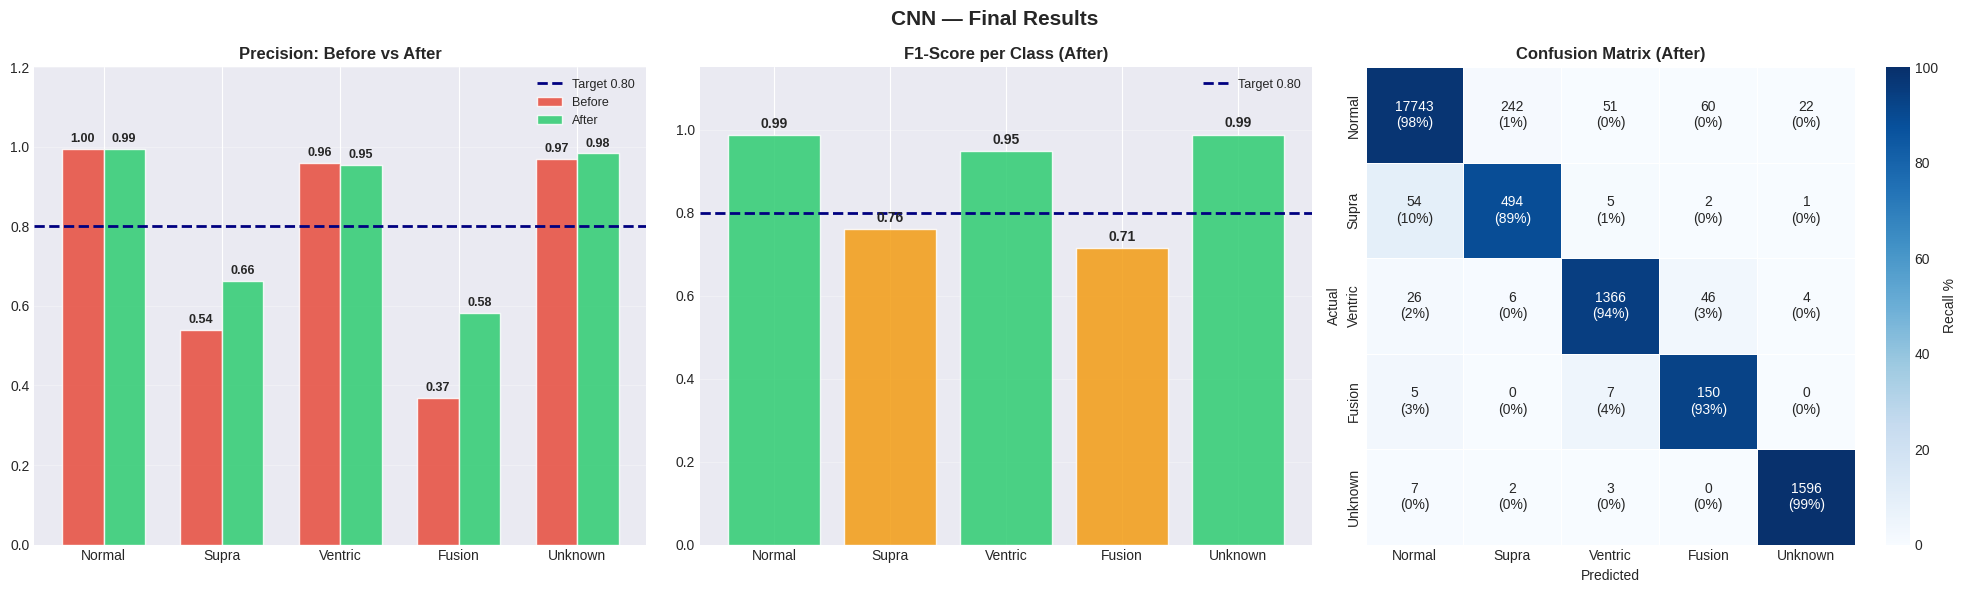


 Precision Summary:
Class               Before      After Status
──────────────────────────────────────────────────
  Normal       :     0.9958      0.9948  ✅
  Supra        :     0.5397      0.6640  🟡
  Ventric      :     0.9592      0.9539  ✅
  Fusion       :     0.3680      0.5814  ❌
  Unknown      :     0.9702      0.9834  ✅

  Macro F1 : 0.8796

✅ CNN Project Complete!


In [108]:
target_names_short = ['Normal', 'Supra', 'Ventric', 'Fusion', 'Unknown']
y_pred_cnn_base    = np.argmax(cnn_model.predict(X_test_dl, verbose=0), axis=1)

prec_before = precision_score(y_test, y_pred_cnn_base,  average=None, zero_division=0)
prec_after  = precision_score(y_test, y_pred_cnn_tuned, average=None, zero_division=0)
f1_after    = f1_score(y_test,        y_pred_cnn_tuned, average=None, zero_division=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CNN — Final Results', fontsize=15, fontweight='bold')

ax = axes[0]
x, w = np.arange(5), 0.35
b1 = ax.bar(x - w/2, prec_before, w, label='Before', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + w/2, prec_after,  w, label='After',  color='#2ecc71', alpha=0.85)
ax.axhline(0.80, color='navy', linestyle='--', linewidth=2, label='Target 0.80')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Precision: Before vs After', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_names_short)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
colors_bar = ['#2ecc71' if v >= 0.80 else '#f39c12' if v >= 0.60 else '#e74c3c' for v in f1_after]
bars = ax2.bar(target_names_short, f1_after, color=colors_bar, alpha=0.85, edgecolor='white')
ax2.axhline(0.80, color='navy', linestyle='--', linewidth=2, label='Target 0.80')
for bar, val in zip(bars, f1_after):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('F1-Score per Class (After)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax3 = axes[2]
cm     = confusion_matrix(y_test, y_pred_cnn_tuned)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
annot  = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.0f}%)" for j in range(5)] for i in range(5)])
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=target_names_short,
            yticklabels=target_names_short,
            linewidths=0.5, linecolor='white', ax=ax3,
            vmin=0, vmax=100, cbar_kws={'label': 'Recall %'})
ax3.set_title('Confusion Matrix (After)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('cnn_final_results.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n Precision Summary:")
print(f"{'Class':15s} {'Before':>10s} {'After':>10s} {'Status'}")
print("─" * 50)
for i, name in enumerate(target_names_short):
    status = '✅' if prec_after[i] >= 0.80 else '🟡' if prec_after[i] >= 0.60 else '❌'
    print(f"  {name:13s}: {prec_before[i]:>10.4f}  {prec_after[i]:>10.4f}  {status}")
macro = f1_score(y_test, y_pred_cnn_tuned, average='macro', zero_division=0)
print(f"\n  Macro F1 : {macro:.4f}")
print("\n✅ CNN Project Complete!")


In [112]:
cnn_model.save("cnn_ecg_final.keras")
cnn_model.save_weights("cnn_weights.weights.h5")
files.download("cnn_weights.weights.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>